In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

ANN_ROOT = Path('../Data/lars_v1.0.0_annotations')
IMG_ROOT = Path('../Data/lars_v1.0.0_images')

# Load annotations and build filename -> (split, bboxes, segments) lookup
ann_by_filename = {}
cat_colors = {}

for split in ['train', 'val']:
    with open(ANN_ROOT / split / 'panoptic_annotations.json') as f:
        data = json.load(f)

    thing_cats = {c['id']: c['name'] for c in data['categories'] if c['isthing']}
    for c in data['categories']:
        cat_colors[c['id']] = [v / 255 for v in c['color']]
    img_meta = {img['id']: img['file_name'] for img in data['images']}

    for ann in data['annotations']:
        fname = img_meta[ann['image_id']]
        bboxes = [
            (*seg['bbox'], thing_cats[seg['category_id']])
            for seg in ann['segments_info']
            if seg['category_id'] in thing_cats
        ]
        ann_by_filename[fname] = {
            'split':    split,
            'bboxes':   bboxes,
            'segments': ann['segments_info'],
            'mask_file': ann['file_name'],
        }

print(f'Loaded annotations for {len(ann_by_filename):,} images')


Loaded annotations for 2,803 images


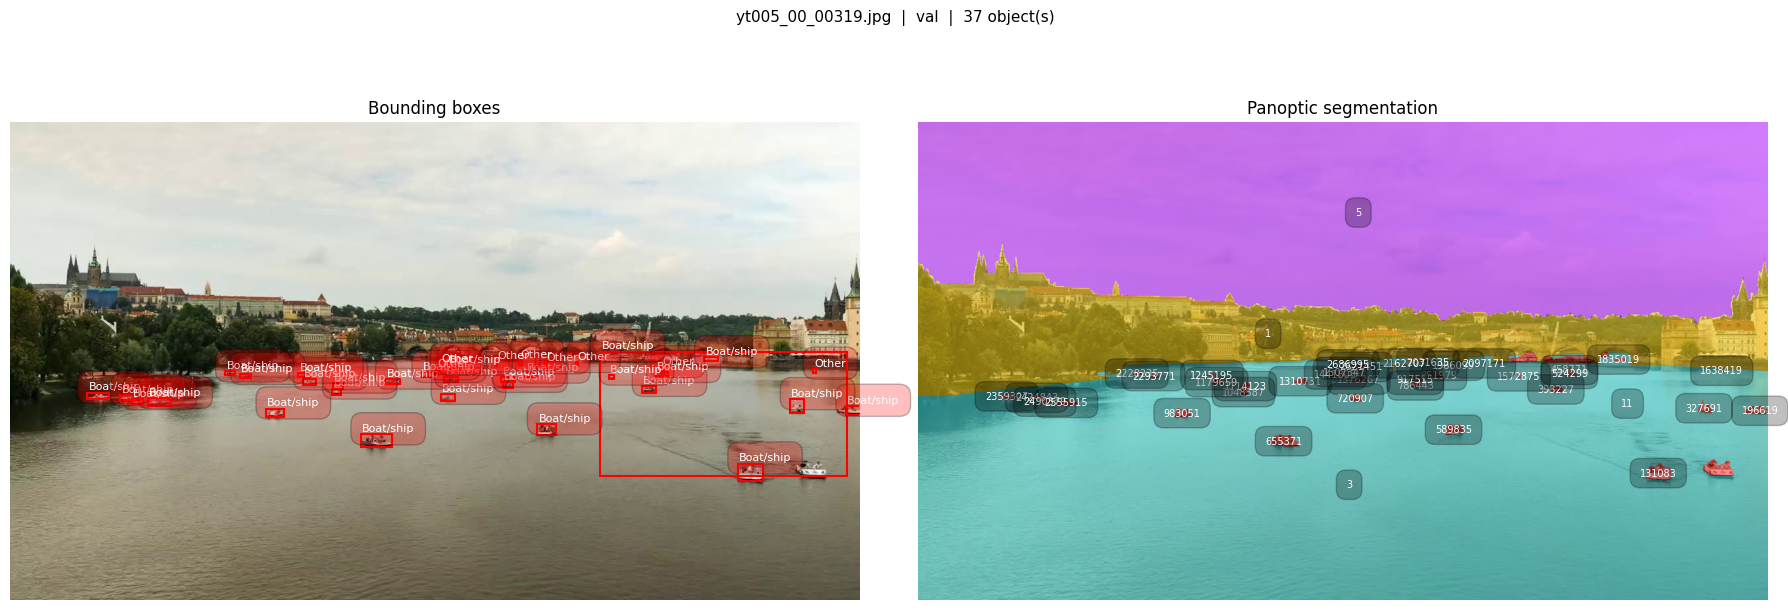

In [11]:
IMAGE_NAME = 'yt005_00_00319.jpg'  # <-- change this

meta      = ann_by_filename[IMAGE_NAME]
split     = meta['split']
bboxes    = meta['bboxes']
segments  = meta['segments']
mask_file = meta['mask_file']

img_arr  = np.array(Image.open(IMG_ROOT / split / 'images' / IMAGE_NAME).convert('RGB'))
mask_arr = np.array(Image.open(ANN_ROOT / split / 'panoptic_masks' / mask_file).convert('RGB'))

# Decode per-pixel segment IDs (COCO panoptic encoding)
seg_id_map = (mask_arr[:, :, 0].astype(np.int32)
              + mask_arr[:, :, 1].astype(np.int32) * 256
              + mask_arr[:, :, 2].astype(np.int32) * 65536)

# Build colour overlay
overlay = img_arr.astype(np.float32) / 255.0
for seg in segments:
    px    = seg_id_map == seg['id']
    color = cat_colors.get(seg['category_id'], [1, 0, 0])
    overlay[px] = overlay[px] * 0.5 + np.array(color) * 0.5

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: image with bounding boxes
axes[0].imshow(img_arr)
for x, y, w, h, cat in bboxes:
    axes[0].add_patch(patches.Rectangle((x, y), w, h,
                                         linewidth=1.5, edgecolor='red', facecolor='none'))
    axes[0].text(x + 2, y - 4, cat, color='white', fontsize=8,
                 bbox=dict(facecolor='red', alpha=0.25, pad=1, boxstyle='round'))
axes[0].set_title('Bounding boxes')
axes[0].axis('off')

# Right: panoptic overlay with segment ID at bbox center
axes[1].imshow(overlay)
for seg in segments:
    if 'bbox' not in seg or not seg['bbox']:
        continue
    x, y, w, h = seg['bbox']
    cx, cy = x + w / 2, y + h / 2
    axes[1].text(cx, cy, str(seg['id']), color='white', fontsize=7, ha='center', va='center',
                 bbox=dict(facecolor='black', alpha=0.25, pad=1, boxstyle='round'))
axes[1].set_title('Panoptic segmentation')
axes[1].axis('off')
plt.suptitle(f'{IMAGE_NAME}  |  {split}  |  {len(bboxes)} object(s)', fontsize=11)
plt.tight_layout()
plt.show()


Segment info: {'id': 11, 'category_id': 11, 'area': 2195, 'bbox': [889, 345, 372, 188], 'iscrowd': 1}
Pixel count : 2195
x range     : 889 – 1260
y range     : 345 – 532
mean  (x,y) : (1070, 424)
median(x,y) : (1007, 361)


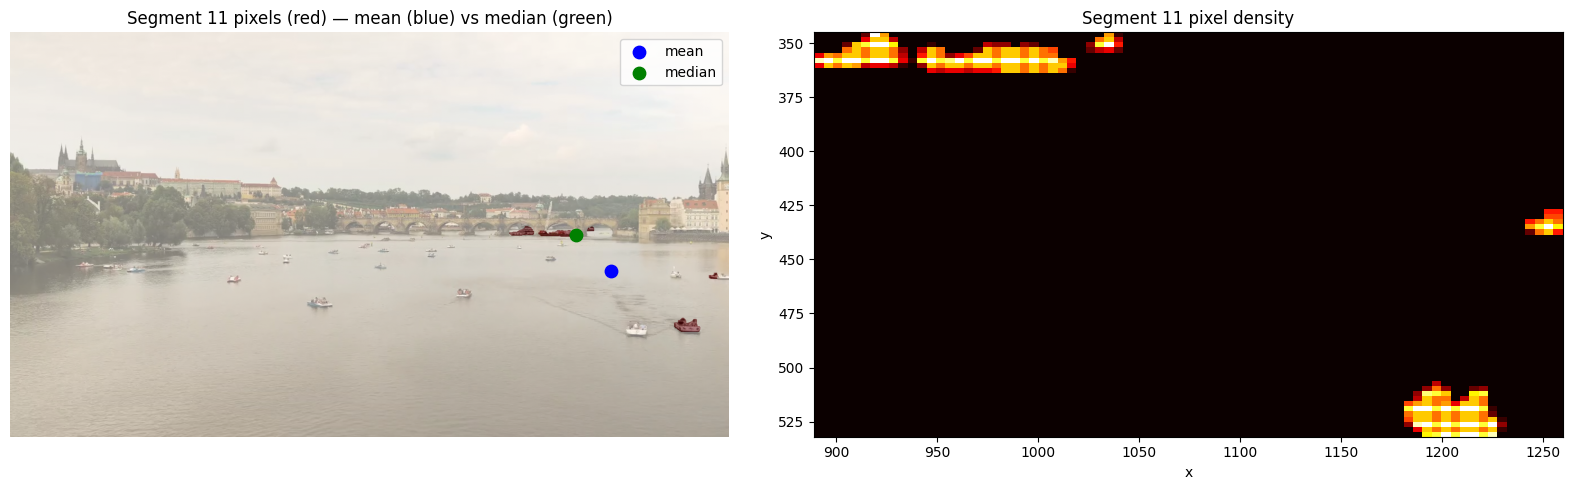

In [12]:
SEGMENT_ID = 11  # <-- change this

seg_info = next((s for s in segments if s['id'] == SEGMENT_ID), None)
print('Segment info:', seg_info)

ys, xs = np.where(seg_id_map == SEGMENT_ID)
print(f'Pixel count : {len(xs)}')
print(f'x range     : {xs.min()} – {xs.max()}')
print(f'y range     : {ys.min()} – {ys.max()}')
print(f'mean  (x,y) : ({xs.mean():.0f}, {ys.mean():.0f})')
print(f'median(x,y) : ({np.median(xs):.0f}, {np.median(ys):.0f})')

# Show where the pixels actually are
pixel_mask = (seg_id_map == SEGMENT_ID).astype(np.uint8) * 255
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(img_arr)
axes[0].imshow(pixel_mask, alpha=0.5, cmap='Reds')
axes[0].scatter([xs.mean()], [ys.mean()], c='blue', s=80, label='mean', zorder=5)
axes[0].scatter([np.median(xs)], [np.median(ys)], c='green', s=80, label='median', zorder=5)
axes[0].legend()
axes[0].set_title(f'Segment {SEGMENT_ID} pixels (red) — mean (blue) vs median (green)')
axes[0].axis('off')

# Pixel density as 2D histogram
axes[1].hist2d(xs, ys, bins=80, cmap='hot')
axes[1].invert_yaxis()
axes[1].set_title(f'Segment {SEGMENT_ID} pixel density')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()


Segment 11 has 5 connected component(s)


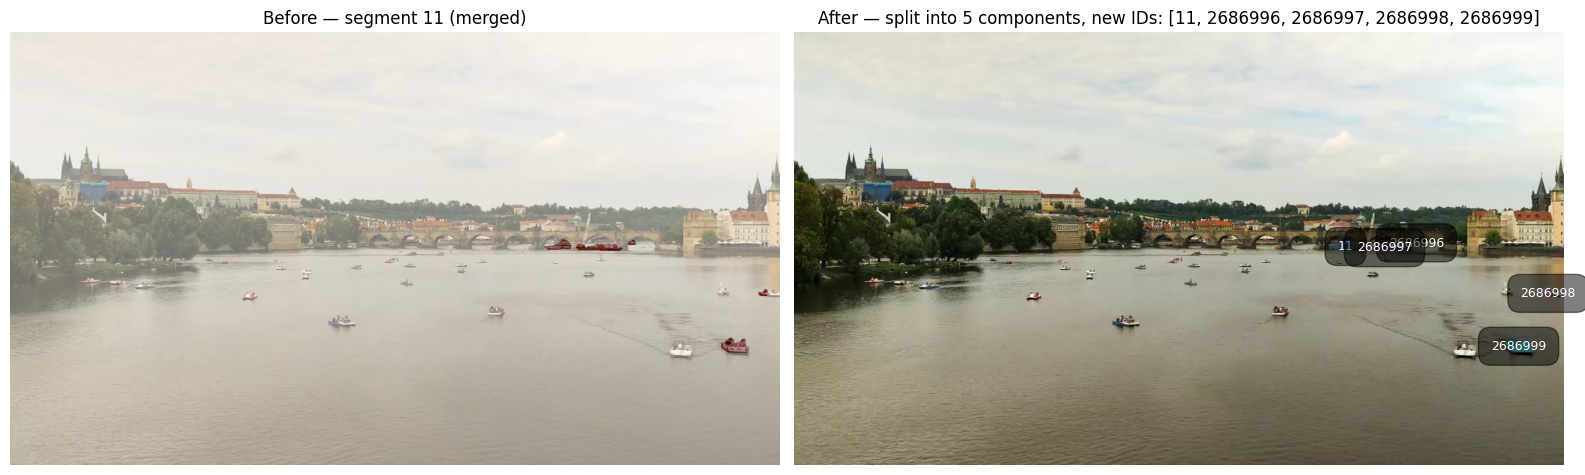

seg_id_map and segments updated in memory. Re-run the visualization cell to see the full result.


In [13]:
from scipy.ndimage import label as connected_components

SEGMENT_ID = 11  # <-- segment to split

mask = (seg_id_map == SEGMENT_ID)
labeled, n = connected_components(mask)
print(f'Segment {SEGMENT_ID} has {n} connected component(s)')

if n <= 1:
    print('Nothing to split.')
else:
    # Assign new IDs to extra components (keep original ID for component 1)
    next_id  = int(seg_id_map.max()) + 1
    new_ids  = [SEGMENT_ID] + list(range(next_id, next_id + n - 1))

    # Update seg_id_map in memory
    for comp_idx, new_id in zip(range(2, n + 1), new_ids[1:]):
        seg_id_map[labeled == comp_idx] = new_id

    # Update segments list
    orig_seg = next(s for s in segments if s['id'] == SEGMENT_ID)
    ys0, xs0 = np.where(labeled == 1)
    orig_seg['bbox'] = [int(xs0.min()), int(ys0.min()),
                         int(xs0.max() - xs0.min()), int(ys0.max() - ys0.min())]
    for comp_idx, new_id in zip(range(2, n + 1), new_ids[1:]):
        ys, xs = np.where(labeled == comp_idx)
        new_bbox = [int(xs.min()), int(ys.min()),
                    int(xs.max() - xs.min()), int(ys.max() - ys.min())]
        segments.append({**orig_seg, 'id': new_id, 'bbox': new_bbox})

    # Visualize
    colors = plt.cm.tab10(np.linspace(0, 0.9, n))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: original merged segment
    axes[0].imshow(img_arr)
    axes[0].imshow(mask, alpha=0.45, cmap='Reds')
    axes[0].set_title(f'Before — segment {SEGMENT_ID} (merged)')
    axes[0].axis('off')

    # Right: split components
    overlay_split = img_arr.astype(np.float32) / 255.0
    for comp_idx, (sid, color) in enumerate(zip(new_ids, colors), start=1):
        px = labeled == comp_idx
        overlay_split[px] = overlay_split[px] * 0.4 + np.array(color[:3]) * 0.6
        ys, xs = np.where(px)
        cx, cy = float(np.median(xs)), float(np.median(ys))
        axes[1].text(cx, cy, str(sid), color='white', fontsize=9,
                     ha='center', va='center',
                     bbox=dict(facecolor='black', alpha=0.5, pad=1, boxstyle='round'))
    axes[1].imshow(overlay_split)
    axes[1].set_title(f'After — split into {n} components, new IDs: {new_ids}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print('seg_id_map and segments updated in memory. Re-run the visualization cell to see the full result.')
